In [ ]:
EJEMPLO DE PCA

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline


In [7]:
# Cargar dataset
data = load_breast_cancer()
print("\n",data)                                                                                                                          
X = data.data          # (569, 30)
y = data.target        # 0 = maligno, 1 = benigno
target_names = data.target_names
print("\n\n",target_names)


 {'data': array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
        1.189e-01],
       [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
        8.902e-02],
       [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
        8.758e-02],
       ...,
       [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
        7.820e-02],
       [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
        1.240e-01],
       [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
        7.039e-02]], shape=(569, 30)), 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 

In [3]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=2, random_state=42))
])

In [4]:
X_pca = pipeline.fit_transform(X)

In [5]:
pca = pipeline.named_steps["pca"]

print("Varianza explicada por componente:")
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f"PC{i+1}: {var:.4f}")

print(f"\nVarianza total explicada: {pca.explained_variance_ratio_.sum():.4f}")


Varianza explicada por componente:
PC1: 0.4427
PC2: 0.1897

Varianza total explicada: 0.6324


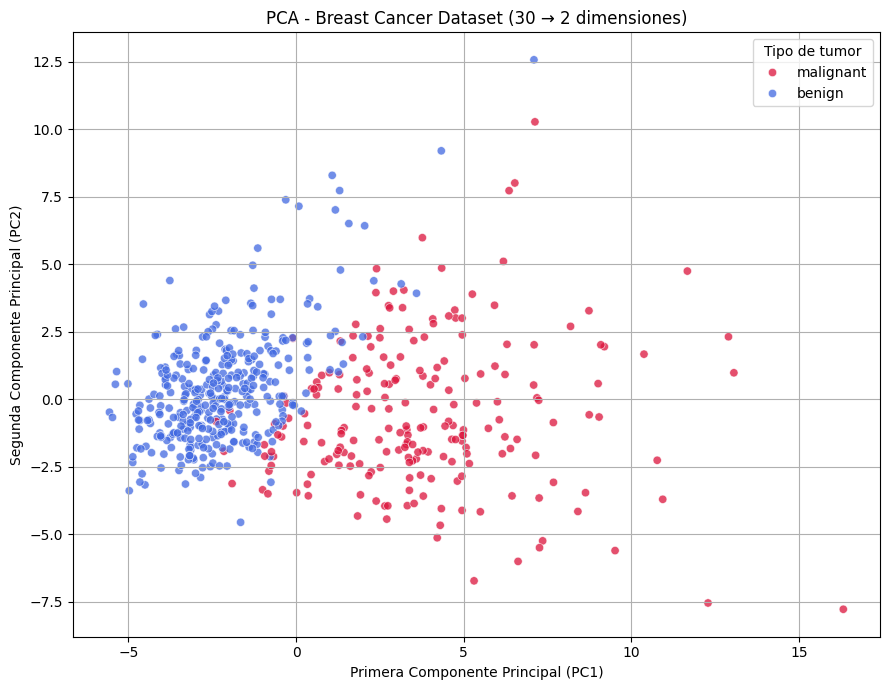

In [6]:
plt.figure(figsize=(9, 7))

sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=[target_names[i] for i in y],
    palette=["crimson", "royalblue"],
    alpha=0.75
)

plt.title("PCA - Breast Cancer Dataset (30 → 2 dimensiones)")
plt.xlabel("Primera Componente Principal (PC1)")
plt.ylabel("Segunda Componente Principal (PC2)")
plt.legend(title="Tipo de tumor")
plt.grid(True)
plt.tight_layout()
plt.show()


loadings = pca.components_.T

import pandas as pd
loading_df = pd.DataFrame(
    loadings,
    columns=["PC1", "PC2"],
    index=data.feature_names
)

print(loading_df.sort_values("PC1", key=np.abs, ascending=False).head(10))
